Embeddings : (2409, 64)
Labels     : (2409, 14)  (14 classes)
Train/Val/Test split: 1445 / 481 / 483
k=2  HL=0.3032  F1=0.4765  t=1.1s
k=3  HL=0.2647  F1=0.5766  t=1.2s
k=4  HL=0.2430  F1=0.5978  t=1.3s
k=5  HL=0.2382  F1=0.6001  t=1.6s
k=6  HL=0.2362  F1=0.6046  t=1.7s
k=7  HL=0.2261  F1=0.6155  t=2.0s


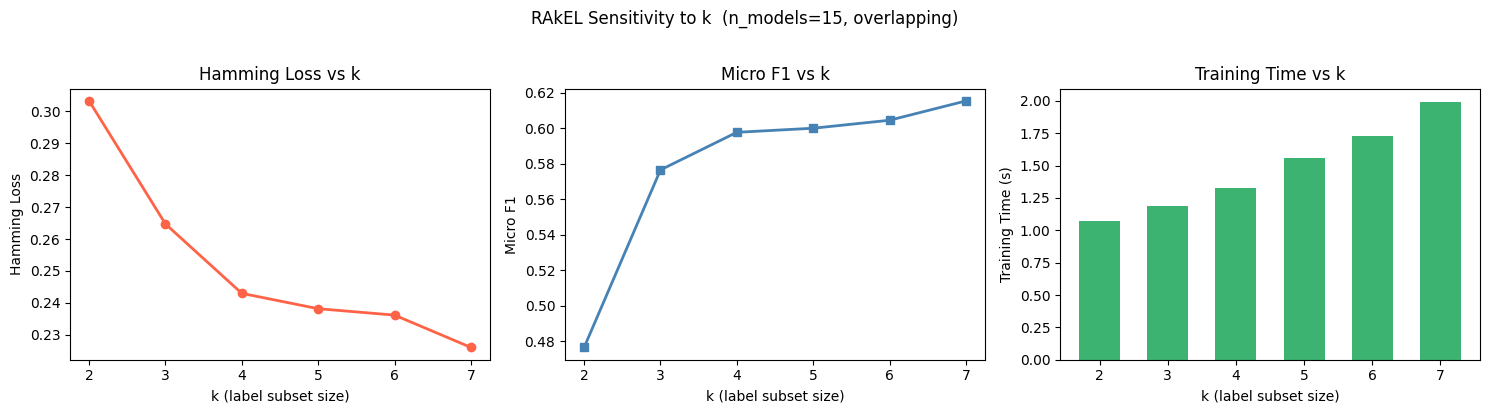

n_models=  2  HL=0.3279  F1=0.1114
n_models=  5  HL=0.3239  F1=0.4033
n_models= 10  HL=0.2780  F1=0.5618
n_models= 15  HL=0.2647  F1=0.5766
n_models= 20  HL=0.2628  F1=0.5834
n_models= 30  HL=0.2419  F1=0.6006
n_models= 40  HL=0.2283  F1=0.6155


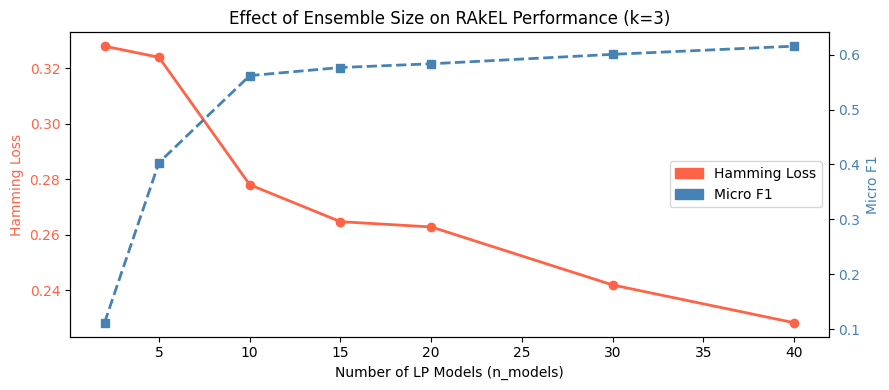

RAkEL + Decision Tree           MicroF1=0.6336  HL=0.2097  t=6.6s
RAkEL + SVM                     MicroF1=0.6344  HL=0.2133  t=10.2s


/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.

RAkEL + Logistic Regression     MicroF1=0.6157  HL=0.2273  t=40.1s


/home/bryan/miniconda3/envs/GTorchCu2.6/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard,Time (s)
Model,,,,,,,
RAkEL + Decision Tree,0.2097,0.1532,0.6336,0.4118,0.6080,0.5013,6.5960
RAkEL + SVM,0.2133,0.2257,0.6344,0.4054,0.6137,0.5191,10.1760
RAkEL + Logistic Regression,0.2273,0.2029,0.6157,0.4229,0.5946,0.4972,40.0790


In [1]:
# ============================================================
# RAkEL Analysis on GNN Embeddings — YEAST Dataset
# ============================================================
# Loads pre-computed GNN embeddings, then benchmarks RAkEL across:
#   1. Sensitivity to label subset size k
#   2. Effect of ensemble size (n_models)
#   3. Comparison of base classifiers
# ============================================================

import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, "./../MAIN/")
from RAkEL import RAkEL
from train import evaluate_multilabel

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH   = "/work/gr-fe/bryan/data/YEAST/03_final/yeast_gnn_embeddings.pkl"
K_DEFAULT  = 3          # label subset size used outside the k-sweep
N_MODELS_DEFAULT = 15   # ensemble size used outside the n_models-sweep
THRESHOLD  = 0.5
RANDOM_STATE = 42

# ── 1. Load embeddings ────────────────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["embeddings"]          # (N, d)
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]
y         = blob["y"].astype(int)       # (N, C) multi-hot
n_labels  = y.shape[1]

print(f"Embeddings : {H.shape}")
print(f"Labels     : {y.shape}  ({n_labels} classes)")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# ── 2. Build train / test sets (train + val → fit, test → evaluate) ───────────
fit_idx = np.concatenate([train_idx, val_idx])
X_train, y_train = H[fit_idx],    y[fit_idx]
X_test,  y_test  = H[test_idx],   y[test_idx]

# ── Helper ────────────────────────────────────────────────────────────────────
def run_rakel(k, n_models, base_clf, X_tr=X_train, y_tr=y_train,
              X_te=X_test, y_te=y_test, mode="overlapping"):
    """Fit a RAkEL model and return (metrics_dict, elapsed_seconds)."""
    model = RAkEL(k=k, n_models=n_models, base_clf=base_clf,
                  mode=mode, threshold=THRESHOLD)
    t0 = time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    elapsed = time() - t0
    metrics = evaluate_multilabel(y_te, y_pred)
    return metrics, elapsed

# ── 3. Sweep k ────────────────────────────────────────────────────────────────
k_range = range(2, min(8, n_labels))
k_results = []

for k in k_range:
    m, t = run_rakel(k, N_MODELS_DEFAULT,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    k_results.append({"k": k, "Hamming Loss": m["Hamming Loss"],
                       "Micro F1": m["Micro F1"], "Time (s)": t})
    print(f"k={k}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}  t={t:.1f}s")

df_k = pd.DataFrame(k_results).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_k.index, df_k["Hamming Loss"], "o-", color="tomato",     lw=2)
axes[1].plot(df_k.index, df_k["Micro F1"],     "s-", color="steelblue",  lw=2)
axes[2].bar(df_k.index,  df_k["Time (s)"],          color="mediumseagreen", width=0.6)
for ax, ylabel, title in zip(
    axes,
    ["Hamming Loss", "Micro F1", "Training Time (s)"],
    ["Hamming Loss vs k", "Micro F1 vs k", "Training Time vs k"]
):
    ax.set_xlabel("k (label subset size)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
fig.suptitle(
    f"RAkEL Sensitivity to k  (n_models={N_MODELS_DEFAULT}, overlapping)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── 4. Sweep n_models ─────────────────────────────────────────────────────────
n_model_range = [2, 5, 10, 15, 20, 30, 40]
nm_results = []

for n_m in n_model_range:
    m, _ = run_rakel(K_DEFAULT, n_m,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    nm_results.append({"n_models": n_m, "Hamming Loss": m["Hamming Loss"],
                        "Micro F1": m["Micro F1"]})
    print(f"n_models={n_m:3d}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}")

df_nm = pd.DataFrame(nm_results).set_index("n_models")

fig, ax1 = plt.subplots(figsize=(9, 4))
color1, color2 = "tomato", "steelblue"
ax1.plot(df_nm.index, df_nm["Hamming Loss"], "o-", color=color1, lw=2)
ax1.set_xlabel("Number of LP Models (n_models)")
ax1.set_ylabel("Hamming Loss", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(df_nm.index, df_nm["Micro F1"], "s--", color=color2, lw=2)
ax2.set_ylabel("Micro F1", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title(f"Effect of Ensemble Size on RAkEL Performance (k={K_DEFAULT})")
plt.legend(
    handles=[mpatches.Patch(color=c, label=l)
             for c, l in [(color1, "Hamming Loss"), (color2, "Micro F1")]],
    loc="center right"
)
plt.tight_layout()
plt.show()

# ── 5. Compare base classifiers ───────────────────────────────────────────────
base_clfs = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM"                : SVC(decision_function_shape="ovo", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs"),
}

clf_results = []
for name, clf in base_clfs.items():
    m, t = run_rakel(k=7, n_models=50, base_clf=clf)
    m["Model"]    = f"RAkEL + {name}"
    m["Time (s)"] = round(t, 3)
    clf_results.append(m)
    print(f"RAkEL + {name:<22s}  MicroF1={m['Micro F1']:.4f}  HL={m['Hamming Loss']:.4f}  t={t:.1f}s")

(
    pd.DataFrame(clf_results)
    .set_index("Model")
    .style
    .background_gradient(subset=["Micro F1", "Sample F1"], cmap="Greens")
    .background_gradient(subset=["Hamming Loss"],           cmap="Reds_r")
    .format(precision=4)
    .set_caption("RAkEL with Different Base Classifiers (k=7, n_models=50)")
)